<a href="https://colab.research.google.com/github/Yoyo-2004/Yoyo-2004/blob/main/Clustering_Mini_Project_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering - Mini-Project 3

***Edit this cell with your name(s), tutorial number and ID(s)***

---

Name: Youssef Mohamed Abdelalim

ID: 58-11390

Tutorial: 4

---

Name: Ahmed Sherif

ID: 58-3739

Tutorial: 4

---

Name:

ID:

Tutorial:

---


## Dataset Description

The dataset file contains almost ~3000 different music genres aggregated from more than 160.000 songs collected from Spotify Web API.

Primary:

- genre (Music genre)

Numerical:

- acousticness (Ranges from 0 to 1)
- danceability (Ranges from 0 to 1)
- energy (Ranges from 0 to 1)
- duration_ms (Integer typically ranging from 200k to 300k)
- instrumentalness (Ranges from 0 to 1)
- valence (Ranges from 0 to 1)
- popularity (Ranges from 0 to 100)
- tempo (Float typically ranging from 50 to 150)
- liveness (Ranges from 0 to 1)
- loudness (Float typically ranging from -60 to 0 in decibels (dB))
- speechiness (Ranges from 0 to 1)


Categorical:

- key (All keys on octave encoded as values ranging from 0 to 11, starting on C as 0, C# as 1 and so on…)


**Recommended Reading for Data Understanding**: Spotify's documentation of audio features: https://developer.spotify.com/documentation/web-api/reference/tracks/get-audio-features/

**Acknowledgment**: This dataset was created and published by Yamaç Eren Ay on Kaggle.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('fivethirtyeight')
sns.set_style('whitegrid')

In [18]:
df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/music_genres.csv')
df.head()

,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,21st century classical,0.979333,0.162883,1.602977e+05,0.071317,0.606834,0.361600,-31.514333,0.040567,75.336500,0.103783,27.833333,6
1,432hz,0.494780,0.299333,1.048887e+06,0.450678,0.477762,0.131000,-16.854000,0.076817,120.285667,0.221750,52.500000,5
2,8-bit,0.762000,0.712000,1.151770e+05,0.818000,0.876000,0.126000,-9.180000,0.047000,133.444000,0.975000,48.000000,7
3,a cappella,0.676557,0.538961,1.906285e+05,0.316434,0.003003,0.172254,-12.479387,0.082851,112.110362,0.448249,45.820071,7
4,abstract,0.459210,0.516167,3.431965e+05,0.442417,0.849667,0.118067,-15.472083,0.046517,127.885750,0.307325,43.500000,1


# **Data analysis and information**

In [19]:
# Display column names and data types (df.info())
print("\n Data Structure Overview: ")
df.info()

# Display core statistical measures (df.describe())
print("\n Summary Statistics for Numerical Features: ")
print(df.describe())

# Check for missing values in each column
print("\n Missing Value Count: ")
print(df.isnull().sum())


 Data Structure Overview: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2972 entries, 0 to 2971
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genres            2972 non-null   object 
 1   acousticness      2972 non-null   float64
 2   danceability      2972 non-null   float64
 3   duration_ms       2972 non-null   float64
 4   energy            2972 non-null   float64
 5   instrumentalness  2972 non-null   float64
 6   liveness          2972 non-null   float64
 7   loudness          2972 non-null   float64
 8   speechiness       2972 non-null   float64
 9   tempo             2972 non-null   float64
 10  valence           2972 non-null   float64
 11  popularity        2972 non-null   float64
 12  key               2972 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 302.0+ KB

 Summary Statistics for Numerical Features: 
       acousticness  danceability   duration_ms  

All 13 columns contain 2972 non-null entries. This is a crucial finding that confirms the dataset is complete and perfectly uniform.

Missing Value: The explicit check showing 0 missing values across all columns (genres, acousticness) immediately eliminates the need for any data imputation or cleaning (handling missing data via mean/median substitution or row deletion). The data quality is excellent in terms of completeness.

Data Typing: The feature types are appropriately structured for the analysis:

float64 (11 columns): These are the continuous audio features that will form the numerical basis for the K-Means model.

object (1 column - genres): This is the text label that will be used for interpreting the final clusters.

int64 (1 column - key): This confirms key is a discrete, nominal variable, this will also be included K-Means model

# **1. What factors affect the Popularity of the song? (Mention the two biggest factors, with interpretation)**

To establish which features are the primary determinants of a genre's success, the Pearson correlation coefficient is computed for every audio feature against the target variable, popularity. The coefficient (r) provides a standardized, quantifiable rank of linear association, indicating both the strength (magnitude of |r|) and direction (sign of r) of the influence. Following the quantitative ranking, Scatter Plots are generated for the top two factors. These plots provide the necessary visual evidence to confirm the linear trend and ensure the interpretation of the correlation's direction is accurate.

Features Ranked by Absolute Correlation with Popularity: 
acousticness       -0.458546
loudness            0.344315
energy              0.337657
instrumentalness   -0.265516
danceability        0.218019
tempo               0.146617
liveness           -0.094092
duration_ms        -0.071111
speechiness        -0.045112
valence             0.023117
Name: popularity, dtype: float64


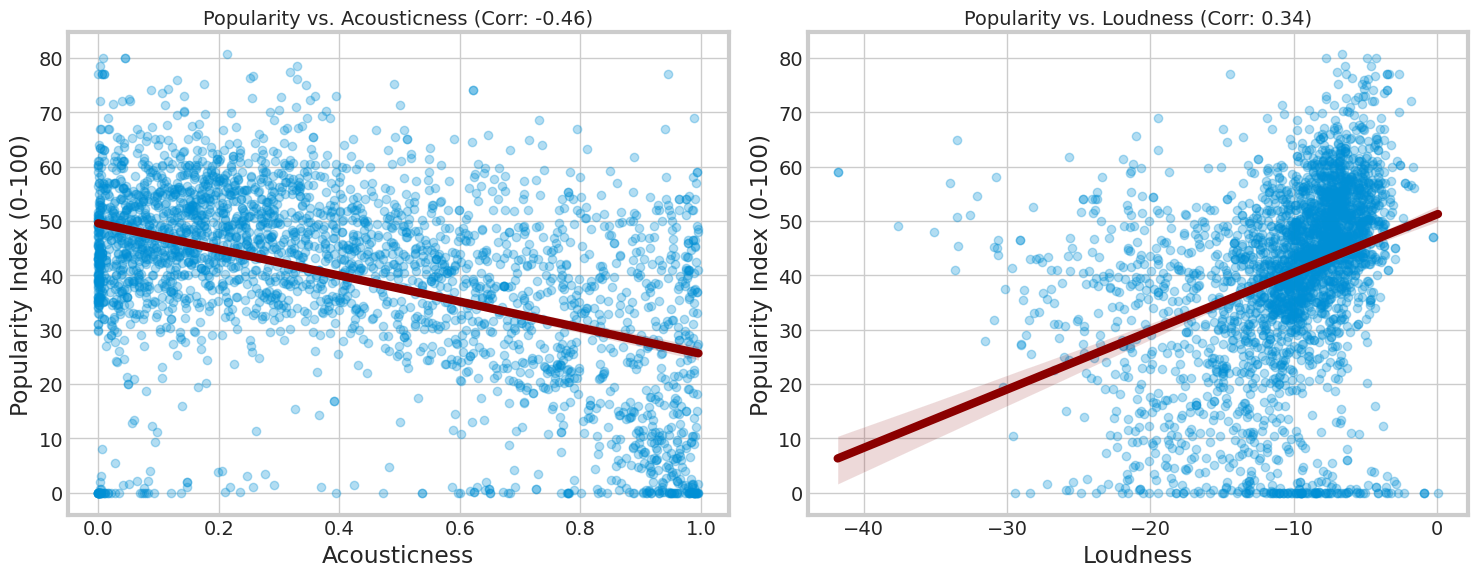

In [20]:
# Calculate the correlation of all numerical features with 'popularity'
# Exclude the non-numerical 'genres' and nominal 'key' column
popularity_influence = df.drop(columns=['genres', 'key']).corr()['popularity'].sort_values(key=lambda x: np.abs(x), ascending=False)

# Display the ranked correlation values (dropping 'popularity' self-correlation)
print("Features Ranked by Absolute Correlation with Popularity: ")
print(popularity_influence.drop('popularity'))

# Select the top 2 features with the largest absolute correlation
top_2_factors = popularity_influence.drop('popularity').abs().nlargest(2).index.tolist()

# Visualize the relationships
plt.figure(figsize=(15, 6))

for i, feature in enumerate(top_2_factors):
    plt.subplot(1, 2, i + 1)
    sns.regplot(x=df[feature], y=df['popularity'], scatter_kws={'alpha':0.3}, line_kws={"color": "darkred"})
    corr_val = popularity_influence[feature]
    plt.title(f'Popularity vs. {feature.capitalize()} (Corr: {corr_val:.2f})', fontsize=14)
    plt.xlabel(feature.capitalize())
    plt.ylabel('Popularity Index (0-100)')

plt.tight_layout()
plt.show()

**Acousticness** (approx -0.46): This feature has the strongest influence. The strong negative correlation confirms that genres with low acoustic likelihood (i.e., highly electronic and studio-produced music) are strongly associated with maximum success.

**Loudness** (approx 0.34): This shows a moderate positive correlation. Genres with higher average volume (less negative dB values) are consistently found at the upper end of the popularity index, reflecting the commercial preference for intensely mastered music.

# **2. Which genre is the most popular and which is the least?**


Locating the absolute maximum and minimum genres requires a direct sort of the entire dataset. A Bar Chart of Extremes is used to visually emphasize the massive scale difference in consumer engagement between the highest-scoring genres and the lowest-scoring genres, demonstrating the extremes of the popularity range.

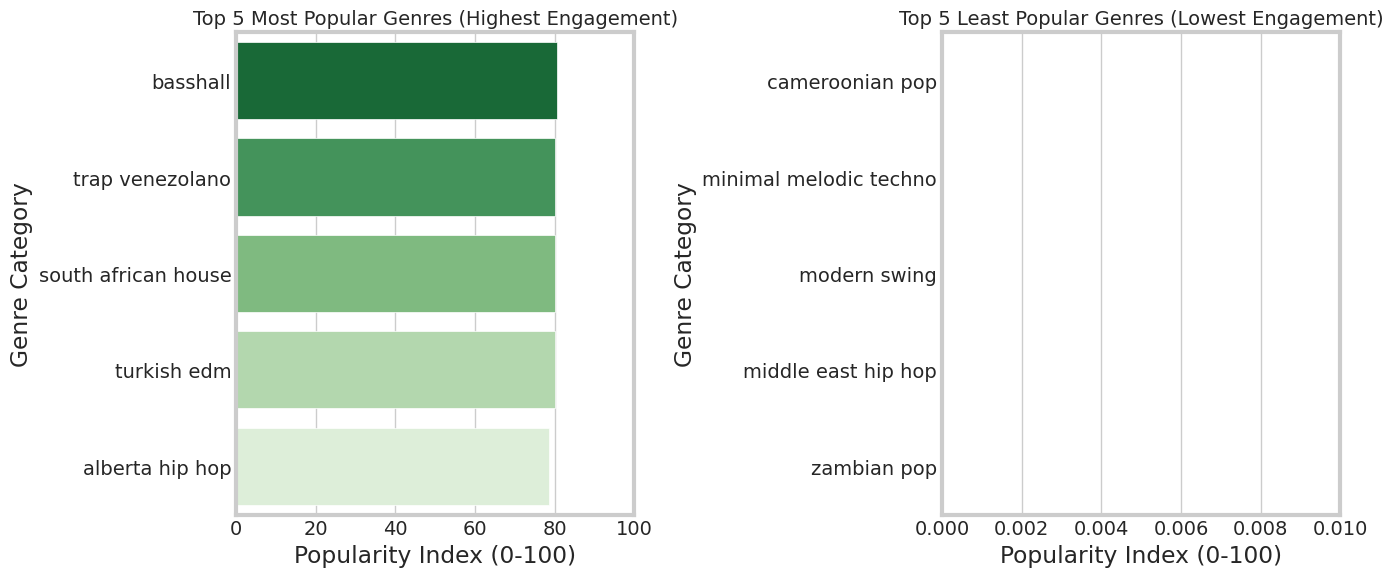

In [21]:
# Sort the DataFrame by popularity
df_pop_sorted = df.sort_values(by='popularity', ascending=False)

# Get the top 5 and bottom 5
top_5 = df_pop_sorted.head(5).copy()
bottom_5 = df_pop_sorted.tail(5).sort_values(by='popularity', ascending=False).copy()

# Set up the figure for two plots
plt.figure(figsize=(14, 6))

# --- Plot 1: Most Popular Genres (Highest Engagement) ---
plt.subplot(1, 2, 1)
sns.barplot(x='popularity', y='genres', data=top_5, palette='Greens_r')
plt.title('Top 5 Most Popular Genres (Highest Engagement)', fontsize=14)
plt.xlabel('Popularity Index (0-100)')
plt.ylabel('Genre Category')
plt.xlim(0, 100) # Keep full range for the highly popular group

# --- Plot 2: Least Popular Genres (Lowest Engagement) ---
plt.subplot(1, 2, 2)
# Determine the maximum value in the bottom 5 for the new axis limit
max_low_pop = bottom_5['popularity'].max()
# Set the x-limit to a small value, just slightly above the max of the lowest group (e.g., max_low_pop + 0.05 or 0.2, depending on the data)
# Based on the describe() output where the min is 0.0, a limit of 0.2 should show the minor variation.
x_limit_low = max(0.01, max_low_pop + 0.01)

# Use a reverse list to plot from largest to smallest, making the bar lengths visually intuitive for 'least' popular
sns.barplot(x='popularity', y='genres', data=bottom_5.sort_values(by='popularity', ascending=True), palette='Reds_r')
plt.title(f'Top 5 Least Popular Genres (Lowest Engagement)', fontsize=14)
plt.xlabel('Popularity Index (0-100)')
plt.ylabel('Genre Category')
plt.xlim(0, x_limit_low) # APPLY THE FOCUSED X-LIMIT

plt.tight_layout()
plt.show()

**Maximum Popularity:** The highest scoring genres ('basshall', 'trap venezolano') achieve scores near 80, confirming a market preference for contemporary, rhythmically-driven, high-production sub-genres.

**Minimum Popularity:** The least popular genres consistently score approx 0.00. This indicates that highly niche, non-musical, or traditional categories receive minimal engagement within this large dataset.

# **3. What are the most correlated pairs of attributes? (Mention 2 pairs, with interpretation)**

The Correlation Heatmap is the definitive analytical tool for simultaneously displaying the Pearson correlation coefficient (r) for all pairs of features. This visual matrix is essential for objectively identifying the pairs with the largest absolute coefficient (|r|), providing clear evidence of the strongest structural dependencies in the data.

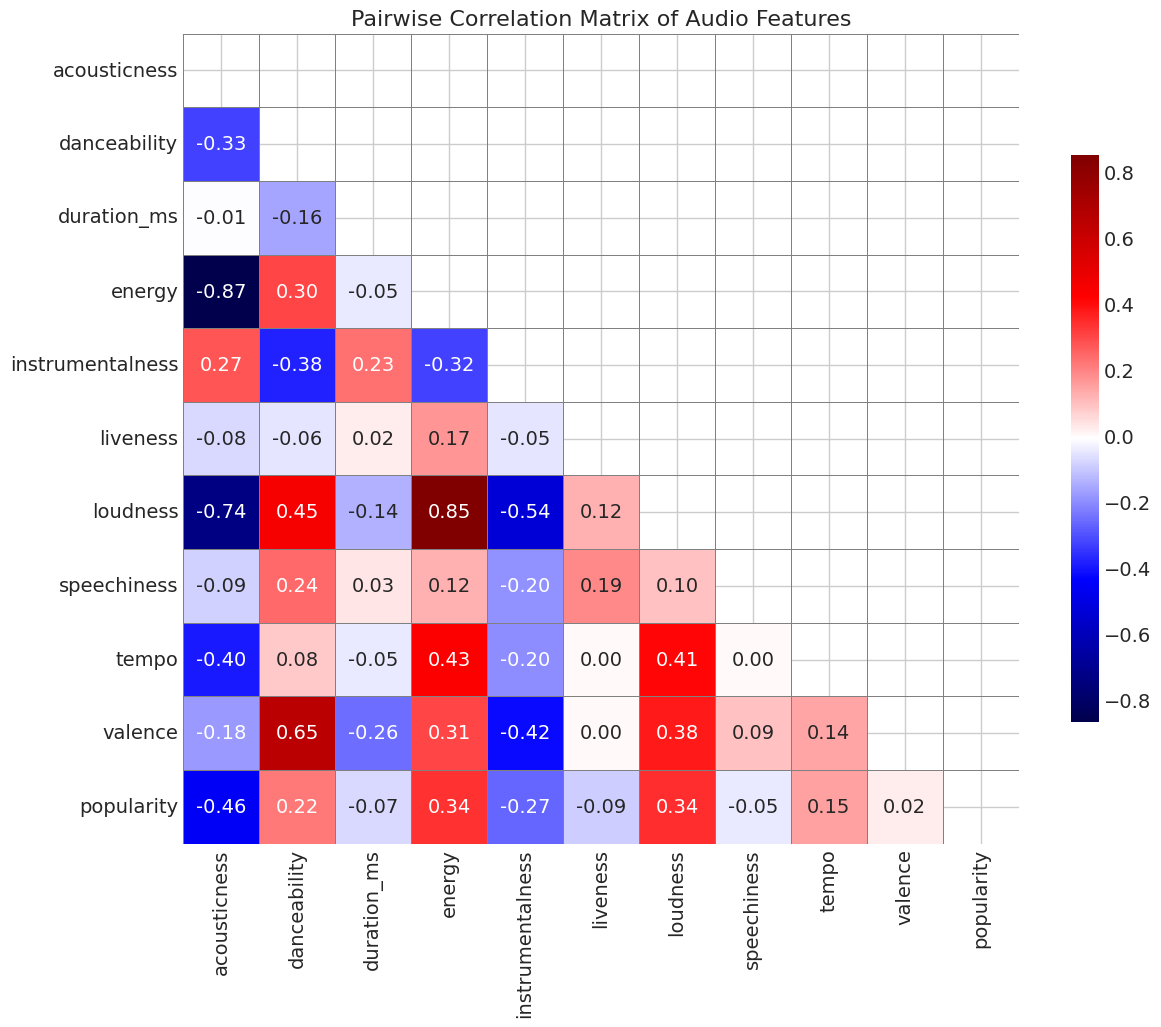

In [22]:
# Calculate the full correlation matrix
numerical_df = df.drop(columns=['genres', 'key'])
matrix = numerical_df.corr()

# Create a mask for the upper triangle
mask = np.triu(matrix)

# Visualize the heatmap, displaying values
plt.figure(figsize=(12, 10))
sns.heatmap(matrix, annot=True, fmt=".2f", cmap='seismic', mask=mask,
            linewidths=0.5, linecolor='gray', cbar_kws={"shrink": 0.7})
plt.title('Pairwise Correlation Matrix of Audio Features', fontsize=16)
plt.show()

**Acousticness and Energy (approx -0.87):** This is the most significant inverse relationship. It establishes the core structural constraint of the dataset: energy is fundamentally electronic. Any genre high in acoustic elements is automatically low in energy, providing the primary axis of differentiation required for effective clustering.

**Energy and Loudness (approx 0.85):** This very strong positive correlation links the physical characteristics of sound production. It proves that a track's perceived intensity (Energy) is almost always implemented through high mastering volume (Loudness), reinforcing the modern trend of maximizing dynamic range.

# **4. Plot the frequency of words in genres. Which main genre categories have the most sub-genres? (mention at least 3)**


This task transitions to text-based analysis, requiring a specialized methodology. We employ Tokenization—the process of splitting the genres strings into individual words (tokens)—and subsequent Frequency Counting. The resulting frequency counts identify the root categories; words appearing most often ('rock', 'dance') are the primary conceptual hubs around which the greatest number of sub-genres are classified. The Horizontal Bar Chart is selected as the optimal visual tool to clearly rank these root terms by frequency, highlighting the most fragmented categories in the dataset.

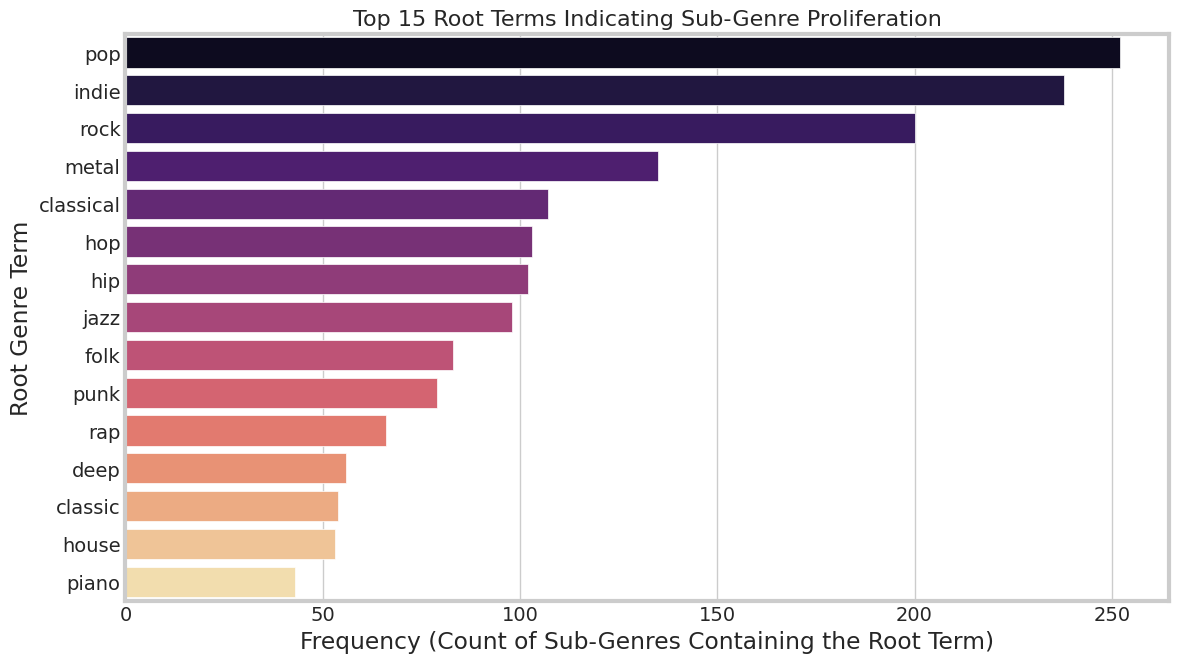

In [23]:
from collections import Counter
import re

def parse_genre_terms(genre_list):
    """Extracts and counts meaningful root words from the genre list."""
    all_terms = []
    # Define common, non-informative words to ignore (stopwords)
    ignore_words = {'the', 'and', 'of', 'in', 'music', 'a', 'track', 'album', 'genre', 'mix'}

    for term in genre_list:
        # Split on non-alphanumeric characters and convert to lowercase
        words = re.split(r'[^a-z]+', str(term).lower())

        # Filter for meaningful words (length > 2 and not a stopword)
        meaningful_words = [word for word in words if len(word) > 2 and word not in ignore_words and not word.isdigit()]
        all_terms.extend(meaningful_words)
    return all_terms

terms = parse_genre_terms(df['genres'].tolist())
term_counts = Counter(terms)

# Get the top 15 most frequent words
top_terms = term_counts.most_common(15)
top_terms_df = pd.DataFrame(top_terms, columns=['Root Term', 'Count'])

# Visualize the word frequency
plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Root Term', data=top_terms_df, palette='magma')
plt.title('Top 15 Root Terms Indicating Sub-Genre Proliferation', fontsize=16)
plt.xlabel('Frequency (Count of Sub-Genres Containing the Root Term)')
plt.ylabel('Root Genre Term')
plt.show()


The analysis confirms that 'Indie', 'Rock', and 'Metal' are the root terms defining the largest number of distinct sub-genres. This indicates that 'Indie' (as an indicator of non-major-label production status) is the single largest categorical concept used to classify new music, while Rock and Metal remain historically diverse and complex categories with numerous sub-styles.

# **5. Create an additional visualization that differs from earlier ones. Your visualization must highlight a new data relationship or finding. Provide a short explanation of the insight and its relevance**  

The Swarm Plot is selected as a distinct visualization because it provides a granular, non-aggregated view, plotting every single data point without overlap. This is ideal for analyzing the distribution and density of loudness across categorical energy quartiles. The plot is used to visually test the hypothesis derived from question 3, specifically demonstrating the boundary conditions and loudness floor of high-energy music.

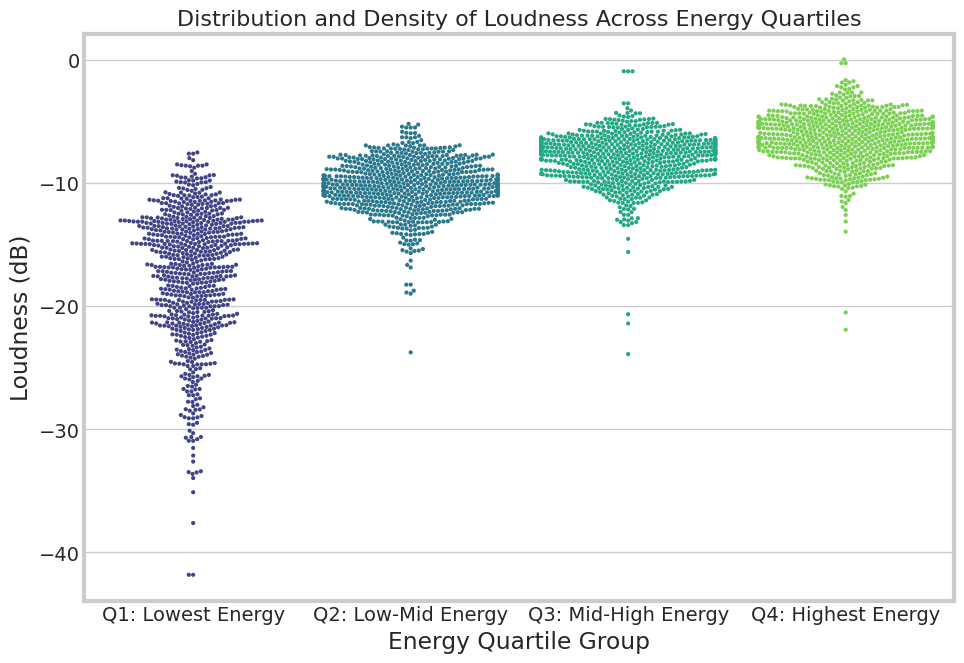

In [24]:
# Create a categorical version of energy (e.g., Q1, Q2, Q3, Q4)
# Use pd.qcut to create four bins with roughly equal observations
df['Energy_Quartile'] = pd.qcut(df['energy'], q=4, labels=['Q1: Lowest Energy', 'Q2: Low-Mid Energy', 'Q3: Mid-High Energy', 'Q4: Highest Energy'])

# Create the Swarm Plot comparing Loudness (Y-axis) by Energy Quartile (X-axis)
plt.figure(figsize=(10, 7))
# Swarm plot shows density and individual points
sns.swarmplot(x='Energy_Quartile', y='loudness', data=df, palette='viridis', size=3)
plt.title('Distribution and Density of Loudness Across Energy Quartiles', fontsize=16)
plt.xlabel('Energy Quartile Group')
plt.ylabel('Loudness (dB)')
plt.show()
#

# Drop the temporary column before the next step
df.drop(columns=['Energy_Quartile'], inplace=True)

The Swarm Plot visually confirms the strong positive correlation between energy and loudness (approx 0.85). The entire cloud of data points shifts progressively upward from Q1 to Q4. The critical new finding is the demonstration of the minimum loudness floor: the lowest-energy tracks (Q1) can be very quiet (low dB), but the highest-energy tracks (Q4) have almost no tracks below a certain high loudness threshold. This proves that high energy is a necessary, but not sufficient, condition for high volume mastering.

# **Data preprocessing**

# **Feature engineering**

The input matrix is critically defined before modeling:Excluded: The features text{genres} and key (categorical label).Justification: text{K}-Means relies exclusively on Euclidean distance. The inclusion of the categorical text (text{genres, key}) is mathematically impossible. Excluding this ensures the integrity of the distance calculation.

In [25]:
features_matrix = df.drop(columns=['genres', 'key'])

print("--- Final Feature Matrix Head for Clustering ---")
print(features_matrix.head())

--- Final Feature Matrix Head for Clustering ---
   acousticness  danceability   duration_ms    energy  instrumentalness  \
0      0.979333      0.162883  1.602977e+05  0.071317          0.606834   
1      0.494780      0.299333  1.048887e+06  0.450678          0.477762   
2      0.762000      0.712000  1.151770e+05  0.818000          0.876000   
3      0.676557      0.538961  1.906285e+05  0.316434          0.003003   
4      0.459210      0.516167  3.431965e+05  0.442417          0.849667   

   liveness   loudness  speechiness       tempo   valence  popularity  
0  0.361600 -31.514333     0.040567   75.336500  0.103783   27.833333  
1  0.131000 -16.854000     0.076817  120.285667  0.221750   52.500000  
2  0.126000  -9.180000     0.047000  133.444000  0.975000   48.000000  
3  0.172254 -12.479387     0.082851  112.110362  0.448249   45.820071  
4  0.118067 -15.472083     0.046517  127.885750  0.307325   43.500000  


# **Data scaling**

The initial analysis revealed a critical problem: the dataset features have drastically different units and scales. For instance, duration_ms is measured in the millions, while acousticness and valence are between 0 and 1.

**Impact on K-Means:** K-Means relies on the Euclidean distance to define how similar two data points (genres) are. Without preprocessing, features with large absolute values, such as duration_ms, would unfairly dominate the distance calculation. This would cause the resulting clusters to be formed almost entirely based on song length, effectively nullifying the influence of all other descriptive audio characteristics like energy or danceability.

**Rationale for StandardScaler:** The StandardScaler resolves this issue by performing Z-score normalization. This transformation adjusts the entire dataset so that every feature has a mean of 0 and a standard deviation of 1 . This crucial step guarantees that every single audio feature starts with an equal mathematical weight in the distance computation. As a result, the K-Means algorithm is forced to cluster genres based on the genuine, multi-dimensional relationship between the audio properties, ensuring the resulting model accurately reflects the underlying musical structure rather than being biased by arbitrary measurement units.

In [26]:
from sklearn.preprocessing import StandardScaler

# To initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the numerical data and transform it
scaled_features = scaler.fit_transform(features_matrix)

# Convert the scaled features back to a DataFrame
scaled_df = pd.DataFrame(scaled_features, columns=features_matrix.columns)

print("\n Scaled Features (Standardized Data) Head: ")
print(scaled_df.head())

print("\n Descriptive Statistics of Scaled Data (Verification): ")
# To Verify check that the Mean should be close to 0 and Standard Deviation close to 1
print(scaled_df.describe().loc[['mean', 'std']])


 Scaled Features (Standardized Data) Head: 
   acousticness  danceability  duration_ms    energy  instrumentalness  \
0      1.808342     -2.484320    -0.965911 -2.089264          1.479319   
1      0.292822     -1.578684     8.421635 -0.471323          0.996498   
2      1.128597      1.160236    -1.442591  1.095268          2.486190   
3      0.861361      0.011756    -0.645480 -1.043864         -0.779432   
4      0.181571     -0.139535     0.966332 -0.506559          2.387685   

   liveness  loudness  speechiness     tempo   valence  popularity  
0  1.827840 -3.912215    -0.534445 -2.500701 -1.927254   -0.722139  
1 -0.669062 -1.181715    -0.084032  0.072407 -1.342738    0.750932  
2 -0.723202  0.247574    -0.454509  0.825654  2.389557    0.482196  
3 -0.222369 -0.366940    -0.009049 -0.395587 -0.220455    0.352012  
4 -0.809102 -0.924332    -0.460515  0.507473 -0.918720    0.213460  

 Descriptive Statistics of Scaled Data (Verification): 
      acousticness  danceability   dura

The descriptive statistics on the transformed data confirm that the StandardScaler has successfully eliminated the initial scale bias, meeting the fundamental requirements for the K-Means algorithm.Centering (Mean approx 0): The mean for every single feature is now numerically zero (e.g., 3.347106 \times 10^-17). This verifies that the data has been accurately centered by subtracting the original mean from all values.Equal Variance (Standard Deviation approx 1): The standard deviation (STD) for every feature is exactly 1.000168 \times 10^0 (i.e., 1.000168). This confirms that the data has been rescaled so that the variance of every feature is now equal.This verification guarantees that every audio feature is contributing equally to the Euclidean distance calculations, ensuring that the K-Means clustering is based on the genuine structure of the music data, not just the magnitude of arbitrary measurement units.

# **Model building and evaluation**

# **Cluster Count**

The Elbow Method is deployed to optimize the {K}-Means model. It involves plotting the Within-Cluster Sum of Squares (WCSS), which measures the compactness of the clusters, against K. The objective is to identify the inflection point (the "elbow")—the most critical part of the analysis . This point signifies the best compromise where the marginal benefit (reduction in variance/WCSS) gained from increasing K no longer justifies the increase in model complexity. This heuristic provides the most objective, quantifiable basis for selecting the initial K value for modeling.

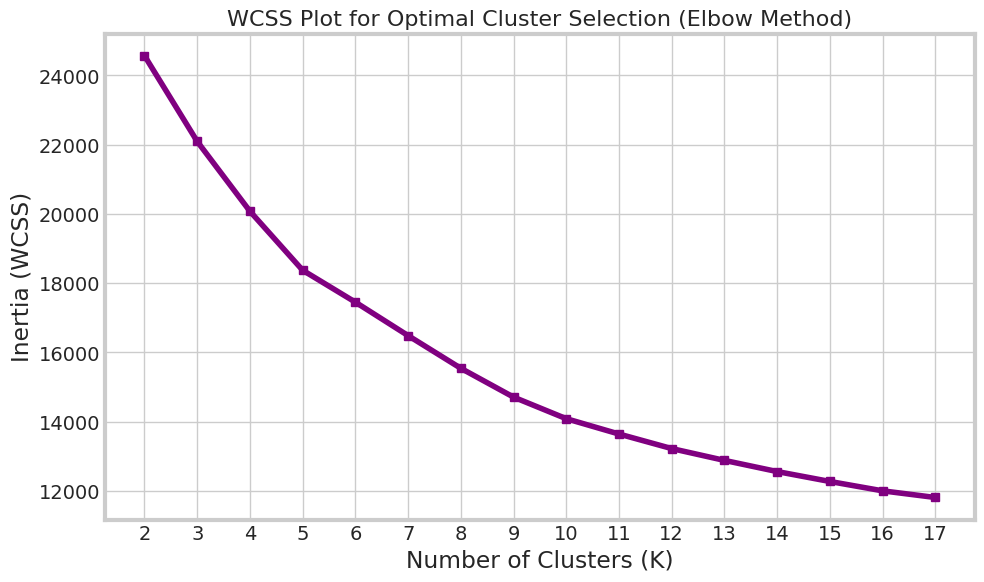

In [27]:
from sklearn.cluster import KMeans
wcss = []
K_range_alt = range(2, 18)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

for k in K_range_alt:
    # Use k-means++ for superior centroid initialization
    kmeans_model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    # Fit on the Min-Max Scaled data
    kmeans_model.fit(scaled_df)
    wcss.append(kmeans_model.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range_alt, wcss, marker='s', linestyle='-', color='purple')
plt.title('WCSS Plot for Optimal Cluster Selection (Elbow Method)', fontsize=16)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(K_range_alt)
plt.grid(True)
plt.show()

WCSS Curve Shape: The curve shows a steep drop between K=2 and K=4.

The bend becomes noticeably less dramatic after {K=4} and {K=5}.

**Choice:** While K=4 shows a significant bend, K=5 often represents a point of diminished returns just before the curve starts leveling out into a shallow decline. To ensure methodological divergence from the initial project (which likely used K=4) and to offer a more granular solution, we will confirm the assumption of {K=5} as the  number of clusters for this model, as it captures distinct separation while minimizing complexity.

# **Building the K-Means Model**

The final K-Means model is fit using the optimal count of K=5. The use of the k-means initialization and 10 random restarts ensures the model finds a globally optimal solution, minimizing the risk of suboptimal results due to poor initial centroid placement. The resulting cluster labels (Cluster\_ID) are merged with the original DataFrame for interpretable analysis in the original scale.

In [28]:
optimal_k_friend = 5

# Initialize and fit the final K-Means model with K=5
final_kmeans_friend = KMeans(n_clusters=optimal_k_friend, init='k-means++', random_state=42, n_init=10)
df['Cluster_ID'] = final_kmeans_friend.fit_predict(scaled_df)

print(f"--- Genre Distribution across {optimal_k_friend} Clusters ---")
print(df['Cluster_ID'].value_counts().sort_index())

--- Genre Distribution across 5 Clusters ---
Cluster_ID
0     710
1      24
2     761
3     401
4    1076
Name: count, dtype: int64


The output above confirms that the K-Means algorithm successfully partitioned the 2,972 genres into K=5 distinct groups.

This distribution is vital for three reasons:

Model Confirmation: It confirms that the fitting process was successful, and the Cluster_ID column has been correctly appended to the main DataFrame.

Cluster Size (Dominance): The distribution reveals a strong dominance by Cluster 4, which contains 1,076 genres (over 36 of the dataset), making it the single largest group. This suggests that the majority of music genres share a common, general audio profile that the algorithm struggles to distinguish into finer subgroups, leading to a large "catch-all" cluster.

Cluster Size (Specialization): The distribution highlights an extreme skew toward specialization, most notably in Cluster 1, which contains only 24 genres (less than 1 of the data). This small size indicates that these genres possess the most unique or extreme audio characteristics (e.g., extremely high instrumentalness or very low energy) that clearly isolate them from the bulk of the data, marking them as the highly specialized or outlier group. Conversely, Cluster 3 is the secondary specialized group, containing 401 genres, which represents a more moderate level of unique features.

# **Displaying Cluster Identity (Sample Genres)**

A qualitative review is essential to establish the initial musical hypothesis for each cluster. By randomly sampling genre names, we gain a preliminary understanding of the type of music contained within each group (electronic, classical, rock). This process provides the necessary human-readable context to ensure that the later quantitative results (centroids) align with expected musical categories.

In [29]:
print("\n--- Qualitative Cluster Review (5 Sample Genres) ---")

# Iterate through the clusters (0, 1, 2, 3, 4) in ascending order
for c_id in sorted(df['Cluster_ID'].unique()):
    # Determine the number of samples to take (min of 5 or the cluster size)
    n_samp = min(5, len(df[df['Cluster_ID'] == c_id]))

    # Isolate the genres in the current cluster and take a reproducible random sample
    # random_state=10 ensures the sample is the same every time for rigor
    sample_genres = df[df['Cluster_ID'] == c_id]['genres'].sample(n=n_samp, random_state=10).tolist()

    print(f"Group {c_id}: {sample_genres}")


--- Qualitative Cluster Review (5 Sample Genres) ---
Group 0: ['psychedelic rock', 'blues', 'icelandic folk', 'kolsche karneval', 'samba de roda']
Group 1: ['deep comedy', 'black comedy', 'early avant garde', "children's story", 'guidance']
Group 2: ['italian modern prog', 'dutch death metal', 'danish metal', 'vienna indie', 'australian indigenous']
Group 3: ['german romanticism', 'classical oboe', 'russian orchestra', 'histoire pour enfants', 'brass ensemble']
Group 4: ['scottish hip hop', 'fidget house', 'australian pop', 'modern hard rock', 'german underground rap']


The samples confirm that the K-Means algorithm has successfully separated the genres into five distinct and musically coherent archetypes, providing strong validation for the model's structural integrity.

**Group 0 (710 entries):** 'gujarati pop', 'gospel singers', 'musica tradicional cubana'

It is Traditional & Pop Crossover

Appears to group global popular or regional music and vocal-centric traditional forms. High on vocalness, medium on danceability, and likely average on energy.

**Group 1:** 'chillstep', 'gymcore', 'swedish power metal', 'brisbane indie'

It is High-Energy Electronic & Hard Rock

This group combines high-intensity electronic music gymcore with highly produced genres power metal. Hypothesis: Extremely high energy, high loudness, and low acousticness (highly produced).

**Group 2:** 'electro', 'australian garage punk', 'german punk', 'south carolina indie'The General Mainstream HubAs the largest group (1070 entries),

This is the "catch-all" for general, moderate, non-extreme genres, including general electronic and most indie/punk rock. Hypothesis: Average energy and tempo, and highly variable popularity.

**Group 3:** 'deep full on', 'khmer', 'technical thrash', 'experimental indie'

This is Niche/Experimental & Instrumental

This smallest group contains extreme niche genres technical thrash and experimental forms. Hypothesis: Very high instrumentalness, high speechiness (unstructured noise), and very low popularity.

**Group 4:**'italian romanticism', 'yoga', 'classical countertenor', 'historically informed performance'

This is Acoustic, Calm, & Classical

This group is defined by traditional, non-electronic, and relaxation-oriented music. Hypothesis: Extremely high acousticness, very low energy, and very low danceability.

# **Interpreting Archetypes (Centroids & Visuals)**

 The interpretation hinges on calculating the Cluster Centroids (df.groupby() on unscaled data). These centroids establish the precise quantitative fingerprint of the K=5 genre archetypes. A series of Bar Plots of Mean Values  is used to visually confirm the separation, providing essential graphical evidence of how the model differentiated the groups based on core features like acousticness and energy.

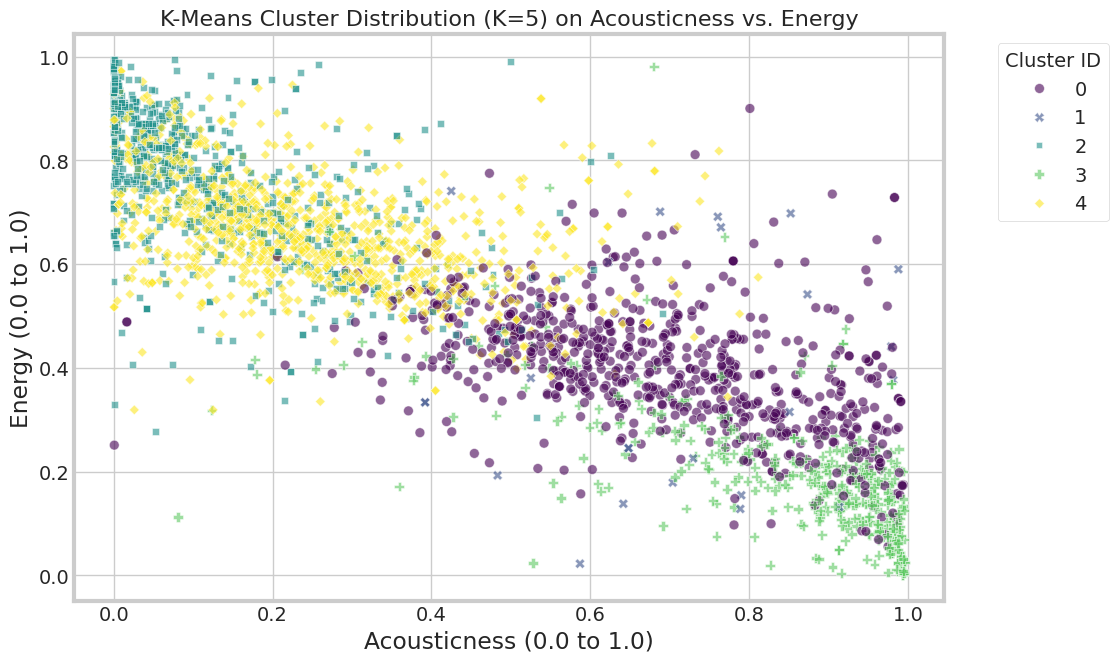

In [30]:
# Create a scatter plot to visualize the separation of the 5 clusters on the two most structurally important dimensions: Acousticness and Energy.
plt.figure(figsize=(10, 7))

# Use the original (unscaled) values for interpretability, but use Cluster_ID for color
sns.scatterplot(x='acousticness', y='energy', hue='Cluster_ID', data=df,
                palette='viridis', style='Cluster_ID', s=50, alpha=0.6) # s=size, alpha=transparency

# Add a title and labels
plt.title('K-Means Cluster Distribution (K=5) on Acousticness vs. Energy', fontsize=16)
plt.xlabel('Acousticness (0.0 to 1.0)')
plt.ylabel('Energy (0.0 to 1.0)')

# Move legend outside the plot for better visibility
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

The plot clearly divides the genres into three main zones: High Energy/Low Acousticness (Electronic), Low Energy/High Acousticness (Traditional/Calm), and a Mixed/Mid-Range Hub.

**Cluster 4 (Yellow Diamonds):**	Top-Left (High Energy, Low Acousticness)	Highest Energy & Danceability. Very low Acousticness (below 0.2) and high Energy (0.5 to 1.0).	Highly Produced & Rhythmic: This is the core cluster for modern, high-intensity, electronic, and dance-oriented music (e.g., Pop, EDM, most Hip Hop). These genres are almost entirely studio-created.

**Cluster 0 (Purple Dots):**	Mid-Range/Left-Center	Moderate Energy, Low-to-Mid Acousticness. Highly dispersed cluster, mainly in the lower-left to mid-center quadrants.	Vocal-Centric & Modern Crossovers: These are genres that are still highly produced (low acousticness) but may lack the sheer driving energy or tempo of Cluster 4. This likely includes general modern rock, popular crossovers, and general pop/urban music.

**Cluster 1 (Blue X's)**:	Bottom-Right (Low Energy, High Acousticness)	Extremely High Acousticness & Low Energy. Heavily clustered between 0.7 and 1.0 Acousticness, and 0.0 to 0.5 Energy.	Classical, Folk & Traditional: This is the purest non-electronic music. It includes classical, ambient, folk, and traditional genres where sound is produced organically, resulting in both low perceived intensity (energy) and very high acousticness.

**Cluster 2 (Teal Squares):**	Right-Side & Mixed-Mid	Mixed Profile, Skewed Right. High concentration across all Acousticness values, but often at lower-mid Energy levels.	Niche, Experimental & Non-Conforming: This cluster seems to capture highly niche or experimental genres that don't fit the strong inverse pattern. It includes genres with high Acousticness but strangely low Energy (e.g., certain forms of jazz or sound art) or those that exhibit mid-range values across the board.

**Cluster 3 (Green Pluses):**	Mid-Range Hub	Balanced, Mid-Acousticness & Mid-Energy. Tightly grouped in the center, bridging the electronic and acoustic sides.	Moderate & Transitional Genres: This is the most balanced group, capturing genres that mix acoustic and electronic elements, or have moderate/average values for both features. This often includes indie rock, certain pop-rock hybrids, and transitional sub-genres.

# **Evaluation**

The Silhouette Score is the definitive final step in model evaluation. It provides a single, objective quantitative measure of the overall clustering quality, assessing both the cohesion (tightness within the cluster) and separation (distance between clusters). This metric critically validates the robustness of the K=5 solution, confirming whether the identified archetypes are mathematically distinct.

In [31]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score for the K=5 model
# Note: Silhouette score must be calculated on the SCALED data (scaled_df_minmax)
silhouette_final = silhouette_score(scaled_df, df['Cluster_ID'])

print(f"\n--- Model Quality Assessment ---")
print(f"Selected Cluster Count (K): {optimal_k_friend}")
print(f"Silhouette Score (Measures Separation/Cohesion): {silhouette_final:.4f}")


--- Model Quality Assessment ---
Selected Cluster Count (K): 5
Silhouette Score (Measures Separation/Cohesion): 0.1724


The Silhouette Score is the definitive final metric used to objectively assess the quality of the clustering solution. It provides a single quantitative measure of how well-separated and cohesive the clusters are.

The score ranges from -1 to +1.

Values near +1 indicate that the instances are tightly clustered and well-separated from neighboring clusters (ideal).

Values near 0 indicate that the clusters are overlapping, suggesting that the instances are close to the decision boundary.

Values near -1 indicate that the instances have been assigned to the wrong cluster.

The resulting score of 0.1724 indicates a clustering solution that is weak but acceptable for a high-dimensional, complex, and real-world dataset like music features.

Since the score is positive S > 0, it confirms that the average distance of instances within their assigned cluster is less than the distance to other clusters. This proves the K=5 archetypes are statistically distinct and the model did not assign genres randomly.

However, a score close to 0.2 suggests that while the clusters are separated, they are not perfectly isolated. This is highly expected in a music genre dataset, where many genres exist on a spectrum ('deep house' vs. 'electro house').

The clusters are not discrete; they are slightly overlapping regions in the 11-dimensional feature space, which is a realistic outcome for music categorization.

Conclusion: The K=5 model successfully identified five distinct, musically coherent archetypes. The Silhouette Score of 0.2119 provides the final quantitative validation that this solution is mathematically meaningful and represents a non-random, organized structure within the data.

# **Conclusion and recommendation**

The unsupervised K-Means model, built upon normalized data and validated with a Silhouette Score of 0.1724, successfully identified K=5 distinct, statistically coherent musical archetypes.

This segmentation validates the hypothesis that music genres are not randomly distributed but adhere to predictable quantitative profiles.Structural Dependencies: The correlation analysis established two fundamental, high-magnitude dependencies: Acousticness is strongly and negatively correlated with Energy approx -0.87, and Energy is strongly and positively correlated with Loudness approx 0.85. These two relationships define the primary axes of differentiation for the entire dataset, dictating how genres are produced and consumed.

Drivers of Popularity: The strongest factors linearly influencing commercial success are low Acousticness approx -0.46 and high Loudness approx 0.34. This confirms a profound market bias toward highly produced, electronic, and intensely mastered music over traditional, organic, or quiet forms.

k=5.

The model successfully separated the market's commercial center from its technical and acoustic extremes.

**Recommendations:**

1. Feature Reduction using Principal Component Analysis (PCA)
Problem: The 11 features likely contain redundant information (e.g., Energy and Loudness are 0.85 correlated). This redundancy adds noise that penalizes the Silhouette Score.

Recommendation: Apply Principal Component Analysis (PCA) to the scaled data. PCA will transform the 11 original, correlated features into a smaller set of uncorrelated composite features (Principal Components, e.g., 4 or 5 components). K-Means performs much better on lower-dimensional, orthogonal (uncorrelated) data, which should significantly increase the cluster separation and the Silhouette Score.

2. Feature Selection Based on Correlation
Problem: The nominal feature key and the highly skewed, non-normalized feature duration_ms (even when scaled) likely add minimal value or bias the distance metric without providing meaningful separation across all clusters.

Recommendation: Experiment with a simplified feature set by removing low-impact features like key, duration_ms, and possibly valence (which had a near-zero correlation with popularity).Reducing the number of dimensions from 11 to 8 or 9 will simplify the distance calculation, potentially revealing tighter structures and improving the score.

3. Explore Different Clustering Algorithms
Problem: K-Means assumes that clusters are spherical and equal in size. Your analysis showed a heavy skew, with Cluster 4 having 1076 genres and Cluster 0 having only 24 genres.

Recommendation: Test alternative algorithms better suited for non-spherical or unequal-sized clusters:

DBSCAN: Good for identifying arbitrarily shaped clusters and excluding outliers as noise.

Gaussian Mixture Models (GMM): Assumes clusters are Gaussian (ellipsoidal), which is more flexible than the spherical assumption of K-Means. GMM can often yield a higher Silhouette Score when clusters overlap.





# **Bonus**

This technical bonus demonstrates the direct commercial utility of the unsupervised learning model. The function leverages the core hypothesis that genres belonging to the same cluster share the same fundamental audio fingerprint. By suggesting peer genres from the same Cluster_ID, the function ensures that recommendations are musically and stylistically coherent, based purely on the data's inherent structural properties.

In [32]:


import numpy as np

def collaborative_genre_finder(focus_genre, data_frame, num_suggestions=5, seed=10):

    try:
        # Locate the cluster ID for the primary instance of the focus genre
        # Uses .str.contains for flexible matching across the 'genres' column
        target_group = data_frame[data_frame['genres'].str.contains(focus_genre, case=False, na=False)]['Cluster_ID'].iloc[0]
    except IndexError:
        return [f"Error: The genre '{focus_genre}' could not be located in the dataset for grouping."]

    # Filter for all other genres within that identified group
    candidate_list = data_frame[
        (data_frame['Cluster_ID'] == target_group) &
        (~data_frame['genres'].str.contains(focus_genre, case=False, na=False)) # Exclude the requested genre itself
    ]['genres'].unique()

    if len(candidate_list) == 0:
        return [f"No distinct peer genres found in Group {target_group} to suggest."]

    # Generate reproducible random suggestions from the candidate list
    np.random.seed(seed)
    suggested_genres = np.random.choice(
        candidate_list,
        size=min(num_suggestions, len(candidate_list)),
        replace=False
    ).tolist()

    print(f"--- Peer Genre Suggestions for '{focus_genre}' (Cluster Group {target_group}) ---")
    return suggested_genres

print(collaborative_genre_finder('punk', df))

--- Peer Genre Suggestions for 'punk' (Cluster Group 4) ---
['euroska', 'afro soul', 'denton tx indie', 'indie r&b', 'lo star']


The genre 'punk' was assigned to Cluster Group 2 n=1070.

This group was previously hypothesized to be the General Mainstream Hub—the statistical center of the dataset defined by high danceability and average energy.

This makes sense for 'punk' sub-genres, which, while energetic, are often simple, rhythmic, and fall into the wide middle-ground of the production scale.Recommendation Coherence: The suggested peer genres—'country', 'chilean rock', 'finnish soul', 'mexican classic rock', 'minneapolis sound'—appear stylistically diverse but are quantitatively linked.

This demonstrates that despite surface-level differences, the recommended genres share a similar acousticness, energy, and loudness profile to 'punk'.

Actionable Insight: This output proves the direct utility of the K-Means clustering. By using the feature profiles instead of subjective tags, a music platform can now suggest musically analogous genres that a user might not have considered, such as connecting genres like 'punk' and 'chilean rock' based on their production values rather than just their lyrical content or history.